# Denoising Autoencoders for Image and Text Embeddings

## Image Denoising Autoencoder

This section implements a convolutional autoencoder to denoise images. The goal is to train a model that can reconstruct clean images from noisy inputs, learning a compressed representation of the image data in the process.

### Mounting Google Drive

First, we mount Google Drive to access the image dataset stored there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Preparation for Image Autoencoder

We set up an `ImageDataGenerator` to load and preprocess images. The `target_size` is set to 128x128 pixels, and images are rescaled to a [0, 1] range. `class_mode='input'` is used because the input and output for the autoencoder are the same images.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
# Define constants
IMAGE_SIZE = 128
BATCH_SIZE = 32
# Data generator for loading and preprocessing images
datagen = ImageDataGenerator(rescale=1./255)
data_dir = '/content/drive/MyDrive/pictures/'

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='input'  # Since we are reconstructing the same image
)

Found 4907 images belonging to 1 classes.


### Autoencoder Model Architecture for Images

This section defines the architecture for the convolutional autoencoder. It consists of an encoder that compresses the image into a latent representation and a decoder that reconstructs the image from this latent space.

**Encoder:** Uses convolutional layers and max-pooling for down-sampling, followed by flattening and a dense layer to create a 256-dimensional latent vector.

**Decoder:** Takes the 256-dimensional latent vector, expands it using a dense layer and reshape, then uses convolutional layers and up-sampling to reconstruct the image.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Dense, Flatten, Reshape, Input

# Encoder
def build_encoder(input_shape):
    input_img = Input(shape=input_shape)

    # Convolutional layers + down-sampling
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    # Flatten and compress to latent representation
    x = Flatten()(x)
    latent = Dense(256, activation='relu')(x)

    return Model(input_img, latent, name='encoder')

# Decoder
def build_decoder(latent_dim, input_shape):
    latent_input = Input(shape=(latent_dim,))

    # Fully connected layer to expand back to original image dimensions
    x = Dense(16 * 16 * 256, activation='relu')(latent_input)
    x = Reshape((16, 16, 256))(x)

    # Convolutional layers + up-sampling
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    # Final convolutional layer to reconstruct the original image
    reconstructed_img = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    return Model(latent_input, reconstructed_img, name='decoder')

# Autoencoder
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
latent_dim = 256
encoder = build_encoder(input_shape)
decoder = build_decoder(latent_dim, input_shape)
# Combine encoder and decoder into one model
autoencoder_input = Input(shape=input_shape)
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)
autoencoder = Model(autoencoder_input, decoded_img)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Functional)                 │ (None, 256)                 │      17,148,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Functional)                 │ (None, 128, 128, 3)         │      17,803,395 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,951,683 (133.33 MB)

 Trainable params: 34,951,683 (133.33 MB)

 Non-trainable params: 0 (0.00 B)

### Training the Image Autoencoder

Here, the autoencoder model is trained using the prepared image data. The model is compiled with the Adam optimizer and Mean Squared Error (MSE) as the loss function, which is suitable for image reconstruction tasks. The training runs for 10 epochs.

In [ ]:
epochs = 10
steps_per_epoch = len(train_generator)
history = autoencoder.fit(train_generator, epochs=epochs)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 46s 181ms/step - loss: 0.0565
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0315
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0231
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - loss: 0.0205
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - loss: 0.0194
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - loss: 0.0187
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0180
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - loss: 0.0175
Epoch 9/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - loss: 0.0166
Epoch 10/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - loss: 0.0163


### Visualizing Image Reconstruction Quality

This function visualizes the autoencoder's performance by displaying original images alongside their reconstructed versions. This helps in qualitatively assessing how well the model can reconstruct the input images after passing them through the latent space.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


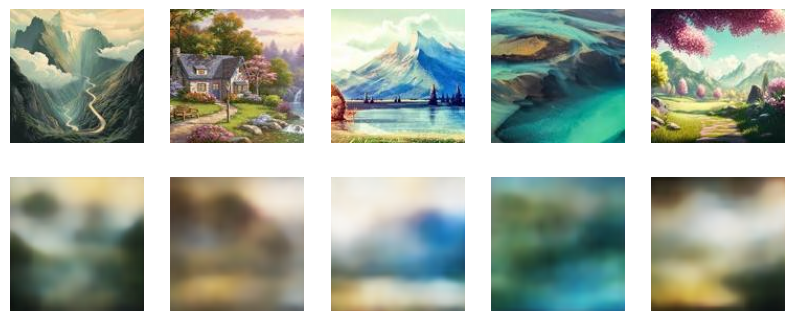

In [ ]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, data_generator, num_images=5):
    data_batch = next(data_generator)[0]
    reconstructed_images = model.predict(data_batch[:num_images])

    plt.figure(figsize=(10, 4))
    for i in range(num_images):
        # Original images
        plt.subplot(2, num_images, i + 1)
        plt.imshow(data_batch[i])
        plt.axis('off')

        # Reconstructed images
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(reconstructed_images[i])
        plt.axis('off')

    plt.show()

# Visualize the reconstruction quality
visualize_reconstruction(autoencoder, train_generator)

### Generating New Images from Latent Space

This function demonstrates the generative capability of the autoencoder's decoder. By sampling random vectors from the latent space and feeding them into the decoder, we can generate new, unseen images that share characteristics with the training data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step


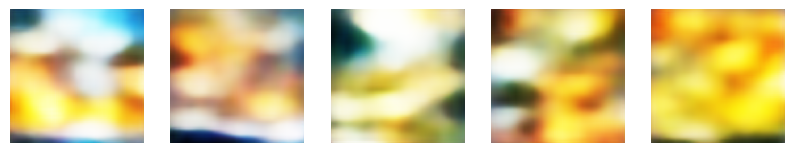

In [ ]:
def generate_new_paintings(decoder, latent_dim, num_samples=5):
    random_latent_vectors = np.random.normal(size=(num_samples, latent_dim))
    generated_images = decoder.predict(random_latent_vectors)

    plt.figure(figsize=(10, 4))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')

    plt.show()

# Generate new paintings from random latent space values
generate_new_paintings(decoder, latent_dim)

### Plotting Training Loss for Image Autoencoder

This plot shows the training loss over epochs, which helps to understand the convergence and performance of the autoencoder during training. A decreasing loss indicates that the model is learning to reconstruct images more accurately.

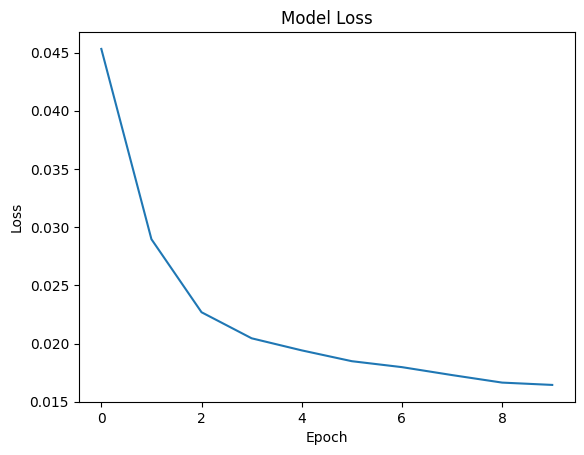

In [ ]:
# training loss
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Denoising Word Embeddings

This section focuses on denoising word embeddings using a simple feed-forward autoencoder. We will train a model to recover clean word embeddings from noisy inputs, thereby improving their quality and robustness.

### Preparing Word Embeddings

Here, we use the NLTK Reuters corpus to train a Word2Vec model, generating initial word embeddings. These embeddings will then be used as the 'clean' data for our denoising autoencoder. `nltk.download` ensures the necessary data is available.

In [ ]:
import gensim
from gensim.models import Word2Vec
import nltk
from nltk.corpus import reuters

nltk.download('reuters')
nltk.download('punkt')

sentences = [' '.join(sent) for sent in reuters.sents()]
sentences = [nltk.word_tokenize(sent) for sent in sentences]

# Train Word2Vec model on the corpus
embedding_dim = 100  # Dimensionality of the embeddings
word2vec_model = Word2Vec(sentences, vector_size=embedding_dim, window=5, min_count=2, workers=4)
clean_embeddings = np.array([word2vec_model.wv[word] for word in word2vec_model.wv.index_to_key])

[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Saving Clean Embeddings

The generated `clean_embeddings` from the Word2Vec model are saved to a `.npy` file for later use, ensuring that the same embeddings can be loaded consistently for training and evaluation.

In [ ]:
np.save('clean_embeddings.npy', clean_embeddings)

### Loading Embeddings and Adding Noise

We load the previously saved clean word embeddings. To simulate noise and create a denoising task, Gaussian noise is added to these clean embeddings, resulting in `noisy_embeddings`.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load pre-trained embeddings (e.g., Word2Vec or GloVe embeddings)
# Here, assume `clean_embeddings` is an (N, D) array where N = number of words and D = embedding dimension
# Replace with actual loading code as per your embeddings' format
clean_embeddings = np.load('clean_embeddings.npy')

# Add Gaussian noise to create a noisy version of the embeddings
noise_factor = 0.2  # Adjust noise level as needed
noisy_embeddings = clean_embeddings + noise_factor * np.random.normal(size=clean_embeddings.shape)


### Autoencoder Model Architecture for Embeddings

This defines a feed-forward autoencoder for word embeddings. The encoder maps the input embedding to a lower-dimensional latent space, and the decoder reconstructs the original embedding from this latent representation. The model is compiled with the Adam optimizer and Mean Squared Error (MSE) loss.

In [ ]:
embedding_dim = clean_embeddings.shape[1]

# Encoder
input_embedding = Input(shape=(embedding_dim,))
encoded = Dense(128, activation='relu')(input_embedding)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(embedding_dim, activation='linear')(decoded)

# Autoencoder model
autoencoder = Model(input_embedding, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          12,900 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,404 (165.64 KB)

 Trainable params: 42,404 (165.64 KB)

 Non-trainable params: 0 (0.00 B)

### Training the Embedding Autoencoder

The autoencoder is trained using the `noisy_embeddings` as input and the `clean_embeddings` as the target output. This process teaches the model to remove the added noise and recover the original embedding structure. Training is performed over 100 epochs with a validation split to monitor performance.

In [ ]:
# Training the autoencoder
epochs = 100
batch_size = 64

history = autoencoder.fit(
    noisy_embeddings, clean_embeddings,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0505 - val_loss: 0.0013
Epoch 2/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0226 - val_loss: 0.0011
Epoch 3/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0172 - val_loss: 7.5069e-04
Epoch 4/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0162 - val_loss: 6.4611e-04
Epoch 5/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0171 - val_loss: 7.1897e-04
Epoch 6/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0128 - val_loss: 6.9929e-04
Epoch 7/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0116 - val_loss: 6.7650e-04
Epoch 8/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0177 - val_loss: 6.3327e-04
Epoch 9/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0114 - val_loss: 6.8745e-04
Epoch 10/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0102 - val_loss: 6.4173e-04
Epoch 11/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0098 - val_loss: 6.2099e-04
Epoch

### Evaluating Denoising Performance with Cosine Similarity

After training, the autoencoder is used to predict `denoised_embeddings` from the noisy inputs. The quality of denoising is then quantified by calculating the average cosine similarity between the original clean embeddings and the denoised embeddings. A higher cosine similarity indicates better reconstruction.

In [ ]:
# Generate denoised embeddings
denoised_embeddings = autoencoder.predict(noisy_embeddings)

# Calculate cosine similarity between clean and denoised embeddings
similarity = cosine_similarity(clean_embeddings, denoised_embeddings).diagonal().mean()
print(f"Average Cosine Similarity between Clean and Denoised Embeddings: {similarity:.4f}")

813/813 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Average Cosine Similarity between Clean and Denoised Embeddings: 0.7221


### Visualizing Embeddings with PCA

To visualize the effect of denoising, Principal Component Analysis (PCA) is used to reduce the dimensionality of a sample of clean, noisy, and denoised embeddings to 2D. This allows for a scatter plot comparison, illustrating how the denoising process moves noisy embeddings closer to their clean counterparts.

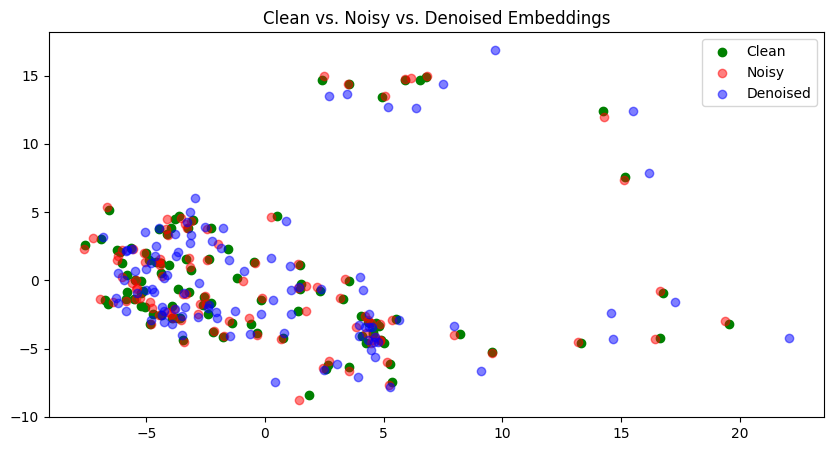

In [ ]:
from sklearn.manifold import TSNE

# Reduce dimensions for visualization
pca = PCA(n_components=2)
clean_2d = pca.fit_transform(clean_embeddings[:100])  # Visualize a sample of 100 embeddings
noisy_2d = pca.transform(noisy_embeddings[:100])
denoised_2d = pca.transform(denoised_embeddings[:100])

plt.figure(figsize=(10, 5))
plt.scatter(clean_2d[:, 0], clean_2d[:, 1], color='g', label='Clean')
plt.scatter(noisy_2d[:, 0], noisy_2d[:, 1], color='r', alpha=0.5, label='Noisy')
plt.scatter(denoised_2d[:, 0], denoised_2d[:, 1], color='b', alpha=0.5, label='Denoised')
plt.legend()
plt.title('Clean vs. Noisy vs. Denoised Embeddings')
plt.show()


### Testing Autoencoder Performance at Different Noise Levels

This section evaluates the robustness of the trained autoencoder by testing its denoising capability across various noise levels. For each noise level, new noisy embeddings are generated, passed through the autoencoder, and the cosine similarity with the clean embeddings is calculated. This provides insights into how well the model generalizes to different degrees of noise.

In [ ]:
# Test the autoencoder performance at different noise levels
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]
for noise in noise_levels:
    noisy_test = clean_embeddings + noise * np.random.normal(size=clean_embeddings.shape)
    denoised_test = autoencoder.predict(noisy_test)
    similarity_test = cosine_similarity(clean_embeddings, denoised_test).diagonal().mean()
    print(f"Noise Level: {noise} - Cosine Similarity: {similarity_test:.4f}")

813/813 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Noise Level: 0.1 - Cosine Similarity: 0.7210
813/813 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Noise Level: 0.2 - Cosine Similarity: 0.7163
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Noise Level: 0.3 - Cosine Similarity: 0.5747
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Noise Level: 0.4 - Cosine Similarity: 0.4416
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Noise Level: 0.5 - Cosine Similarity: 0.3810
